# Arabic Sentiment Analysis
**Birzeit University — Department of Electrical and Computer Engineering**  
**Second Semester 2025-2026 | Second Assignment**

---

**Dataset:** ASTD — Arabic Sentiment Tweets Dataset (3 classes: POS / NEG / NEUTRAL)  
**Goal:** Compare text representation methods and classifiers for Arabic sentiment analysis.

## Imports

In [ ]:
# Add your imports here
import sys
sys.setrecursionlimit(5000)

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

from gensim.models import Word2Vec as GensimW2V, FastText as GensimFT

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, SimpleRNN, LSTM, Dropout, Dense

## Load Dataset

In [2]:
# Load the dataset from ASTD_arabic_sentiment.csv
df = pd.read_csv('real data.txt', sep='\t', header=None, names=['text', 'label'])
# Merge OBJ into NEUTRAL — the assignment treats these as the same class
df['label'] = df['label'].replace('OBJ', 'NEUTRAL')
print(f'Dataset shape: {df.shape}')

Dataset shape: (9694, 2)


---
# 1. Data Exploration

In [3]:
# Basic structure: shape, dtypes, missing values
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9694 entries, 0 to 9693
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    9694 non-null   str  
 1   label   9694 non-null   str  
dtypes: str(2)
memory usage: 151.6 KB
None


- As we can see there are 2 columns, the first column being the text (the post/tweet from the users), and the second column is the label, where the label is what determines under what category/class the tweet falls under. Thankfully no null values yet, however that may change once we process the tweet for stop words or other characters that may be removed.

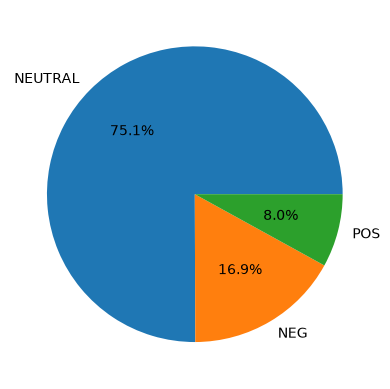

In [52]:
# Class distribution — count and proportion
distribution = df['label'].value_counts()
distribution.plot(kind='pie', autopct='%1.1f%%')
plt.savefig('images/class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

As we can see here the data is mostly Neutral (Imbalanced), where the rest is a third positive with the rest negative.

In [5]:
# Print a few sample tweets per class
for label in df['label'].unique():
    samples = df[df['label'] == label]['text'].head(2).tolist()
    print(f'\n{label}:')
    for sample in samples:
        print(sample)
    print ('='*90)


NEUTRAL:
بعد استقالة رئيس #المحكمة_الدستورية ننتظر استقالة #رئيس_القضاء #السودان
#الحرية_والعدالة | شاهد الآن: #ليلة_الاتحادية أول فيلم استقصائي يتناول أسرار و كواليس تعرض لأول مرة حول حقيقة

POS:
أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر، بمناسبة صدور أولى روايته
امير عيد هو اللي فعلا يتقال عليه ستريكر صريح #كاريوكي #السكة_شمال

NEG:
البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام العريان الي واشنطن شئ مقرف
عودة جماعة الإخوان إلى الحياة السياسية بنفس وضعها السابق مستحيلة والطرمخة على جرائم الماضي لن تجعلنا نتقدم شبرا


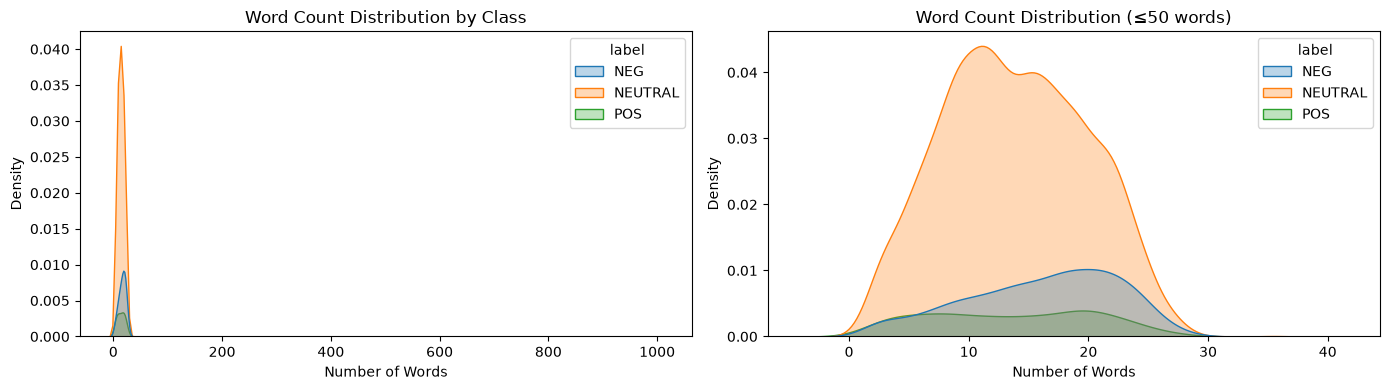

In [53]:
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.kdeplot(data=df, x='word_count', hue='label',
            hue_order=['NEG', 'NEUTRAL', 'POS'],
            fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title('Word Count Distribution by Class')
axes[0].set_xlabel('Number of Words')

sns.kdeplot(data=df[df['word_count'] <= 50], x='word_count', hue='label',
            hue_order=['NEG', 'NEUTRAL', 'POS'],
            fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title('Word Count Distribution (≤50 words)')
axes[1].set_xlabel('Number of Words')

plt.tight_layout()
plt.savefig('images/word_count_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

### Observation
As we can see from the KDE plot, word count does not vary much between classes — for the most part all are right skewed and we see that most tweets are short. So there is no true information gain from the length.

---
# 2. Data Preprocessing

Arabic social media text requires specific cleaning steps before feeding it to any model:

| Step | What to do |
|---|---|
| Noise removal | Remove URLs, HTML tags, @mentions, hashtag symbols, emojis, Latin/digits |
| Tashkeel | Remove short vowel diacritics (rarely appear on social media, inflate vocab) |
| Tatweel | Remove the elongation character ـ |
| Alef normalisation | Map أ / إ / آ → ا |
| Yeh normalisation | Map ى → ي |
| Teh Marbuta | Map ة → ه |
| Non-Arabic removal | Keep only Arabic Unicode range (U+0600–U+06FF) |
| Stop words | Remove common function words with no sentiment value |

### Write the text cleaning function

In [7]:
# Arabic stop words — negation words (لا، لم، ليس، ليست، ولا، ولم) are intentionally excluded
# because removing them flips sentiment (e.g. "لا أحب" → "أحب" changes "I don't like" to "I like")
ARABIC_STOP_WORDS = {
    'في', 'من', 'إلى', 'على', 'أن', 'هذا', 'هذه', 'ذلك', 'التي', 'الذي',
    'وفي', 'وقد', 'كان', 'ما', 'مع', 'بين', 'عن', 'قد', 'كل',
    'له', 'بعد', 'قبل', 'وهو', 'وهي', 'أو', 'هو', 'هي', 'نحن',
    'أنا', 'أنت', 'هم', 'هن', 'عند', 'أيضا', 'حتى', 'إذا', 'لكن',
    'يكون', 'كانت', 'وكان', 'يمكن', 'الذين', 'غير', 'بشكل', 'حيث',
    'بما', 'كما', 'تم', 'مما', 'إن', 'وأن', 'ومن', 'عبر',
    'لأن', 'أنه', 'ذات', 'بل', 'ثم', 'اي', 'أي', 'ال', 'و',
    'ب', 'ل', 'ف', 'ك', 'هل', 'لي', 'لك', 'لنا', 'لهم', 'منه',
    'منها', 'فيه', 'فيها', 'وكل', 'سوف', 'اذ', 'إذ', 'كيف', 'متى',
    'أين', 'انا', 'انت', 'الان', 'الآن', 'ولكن',
    'هناك', 'وهذا', 'وهذه', 'كانوا', 'قالوا', 'وقال', 'وقالت',
    'عليه', 'عليها', 'فقط', 'عليهم', 'لهذا', 'بهذا', 'كذلك',
    'وأيضا', 'مثل', 'وعلى', 'وعن', 'عنه', 'عنها', 'وهم', 'وله',
}

def preprocess_arabic(text: str) -> str:
    if not isinstance(text, str):
        return ''

    # Step 1: Remove web/social noise — must come before punctuation stripping
    # so that @mentions and #hashtags are matched whole before @ and # are removed
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # URLs
    text = re.sub(r'<[^>]+>', '', text)                   # HTML tags
    text = re.sub(r'@\w+', '', text)                      # @mentions
    text = re.sub(r'#(\S+)', r'\1', text)                 # strip # but keep word

    # Step 2: Remove diacritics and decorative characters
    text = re.sub(r'[ً-ٰٟ]', '', text)    # tashkeel (short vowels)
    text = re.sub(r'ـ', '', text)                    # tatweel (elongation ـ)

    # Step 3: Remove Arabic punctuation (،, ؛, ؟ are inside Arabic range so need explicit removal)
    text = re.sub(r'[؀-،؛؟٪-٭۔]', ' ', text)

    # Step 4: Normalize Arabic character variants
    text = re.sub(r'[إأآ]', 'ا', text)   # Alef variants → ا
    text = re.sub(r'ى', 'ي', text)        # Alef Maqsura → Yeh
    text = re.sub(r'ة', 'ه', text)        # Teh Marbuta → Heh
    text = re.sub(r'ؤ', 'و', text)        # Waw with hamza → Waw
    text = re.sub(r'ئ', 'ي', text)        # Yeh with hamza → Yeh

    # Step 5: Keep only Arabic letters and whitespace
    text = re.sub(r'[^ء-غف-ي\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 6: Remove stop words and single-character tokens
    words = [w for w in text.split() if w not in ARABIC_STOP_WORDS and len(w) > 1]
    return ' '.join(words)

### Call the new method over the data and verify it works

In [8]:
# Apply the cleaning function row-by-row to the 'text' column.
df['text_clean'] = df['text'].apply(preprocess_arabic)

# Visual before/after check — lets us verify the pipeline is working as intended.
print('Before / After examples:')
print('='*90)
for i in range(3):
    print(f'\n[{df["label"].iloc[i]}]')
    print(f'  BEFORE: {df["text"].iloc[i]}')
    print(f'  AFTER:  {df["text_clean"].iloc[i]}')


Before / After examples:

[NEUTRAL]
  BEFORE: بعد استقالة رئيس #المحكمة_الدستورية ننتظر استقالة #رئيس_القضاء #السودان
  AFTER:  استقاله رييس المحكمه الدستوريه ننتظر استقاله رييس القضاء السودان

[POS]
  BEFORE: أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر، بمناسبة صدور أولى روايته
  AFTER:  اهني الدكتور احمد جمال الدين القيادي بحزب مصر بمناسبه صدور اولي روايته

[NEG]
  BEFORE: البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام العريان الي واشنطن شئ مقرف
  AFTER:  البرادعي يستقوي بامريكا مرهاخري يرسل عصام العريان الي واشنطن شي مقرف


### Remove any empty rows that were generated from post processing

In [9]:
empty = (df['text_clean'].str.strip() == '').sum()
print(f'\nEmpty texts after preprocessing: {empty}')
df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
print(f'Remaining samples: {len(df)}')

df['text_clean'].info()


Empty texts after preprocessing: 10
Remaining samples: 9684
<class 'pandas.Series'>
RangeIndex: 9684 entries, 0 to 9683
Series name: text_clean
Non-Null Count  Dtype
--------------  -----
9684 non-null   str  
dtypes: str(1)
memory usage: 75.8 KB


### Migrate categories to numeric encodings

In [10]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'NEG': 0, 'NEUTRAL': 1, 'POS': 2}


### Observations

All noise that was deemed unneccessary was removed, hashtags, stop words (words that dont give true meaning becuase they are so common in the language), whitespaces, latin characters, etc...
I have also converted the labels to numeric values to help with the training. 
A handful of rows were dropped which is a good sign for the data quality as of now.
# Emoji Demojization
Although Emojis do provide sentiment, the amount of preprocessing to do so will overcomplicate and take too much effort, I have thought of an effort to make it where we convert emoji to its name and then convert the name to its arabic translation. However that requires too much effort. I do recommend to just remove it and keep it strictly words for now to keep the assignment simple.


---
# 3. Dataset Splitting

Split into **60% train / 20% validation / 20% test** using stratified sampling so each split has the same class proportions.

In [11]:
# Two-step stratified split: 60% train, then 50/50 on the remaining 40%

X = df['text_clean'].to_numpy()
y = df['label_enc'].to_numpy()

# Step 1: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

# Step 2: split temp 50/50 → 20% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f'Train:      {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)')
print(f'Validation: {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)')
print(f'Test:       {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)')

def print_class_balance(y, name):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    print(f'\n{name} ({total} samples):')
    for label, count in zip(unique, counts):
        print(f'  {le.classes_[label]}: {count} ({count/total*100:.1f}%)')

print_class_balance(y_train, 'Train')
print_class_balance(y_val, 'Validation')
print_class_balance(y_test, 'Test')

Train:      5810 (60.0%)
Validation: 1937 (20.0%)
Test:       1937 (20.0%)

Train (5810 samples):
  NEG: 985 (17.0%)
  NEUTRAL: 4360 (75.0%)
  POS: 465 (8.0%)

Validation (1937 samples):
  NEG: 328 (16.9%)
  NEUTRAL: 1454 (75.1%)
  POS: 155 (8.0%)

Test (1937 samples):
  NEG: 328 (16.9%)
  NEUTRAL: 1454 (75.1%)
  POS: 155 (8.0%)


---
# 4. Feature Representations

Fit all vectorisers on **training data only** — never on validation or test.

Three representations:
1. **TF-IDF** — word-level unigrams + bigrams
2. **FastText** — character n-gram TF-IDF (`analyzer='char_wb'`)
3. **Word2Vec (CBOW)** — custom trained with PyTorch, then mean-pool into document vectors


# 4. Data Representation

## 4.1 TF-IDF

In [12]:
# Build TF-IDF feature matrices for train / val / test
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
X_tfidf_train = tfidf.fit_transform(X_train)
X_tfidf_val   = tfidf.transform(X_val)
X_tfidf_test  = tfidf.transform(X_test)

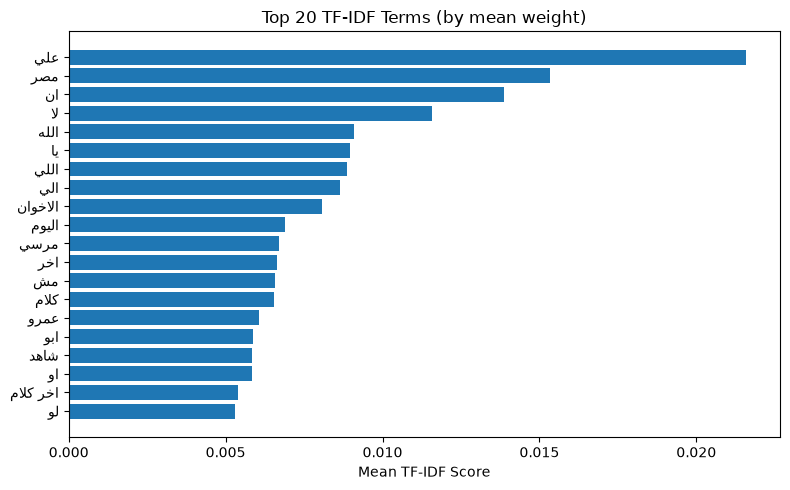

In [54]:
# Top 20 TF-IDF terms by mean weight across training documents
feature_names = tfidf.get_feature_names_out()
mean_scores   = X_tfidf_train.mean(axis=0).A1
top20_idx     = mean_scores.argsort()[-20:][::-1]

plt.figure(figsize=(8, 5))
plt.barh([feature_names[i] for i in top20_idx[::-1]], mean_scores[top20_idx[::-1]])
plt.title('Top 20 TF-IDF Terms (by mean weight)')
plt.xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.savefig('images/tfidf_top20.png', bbox_inches='tight', dpi=150)
plt.show()

### TF-IDF Analysis

TF-IDF converts each tweet into a sparse vector of weighted word and bigram scores, where if a term appears alot in one document but rare in other documents, will receive a higher score.

**Compatible models:** ✓ Naïve Bayes (requires non-negative values — TF-IDF always ≥ 0), ✓ Random Forest. ✗ CNN / RNN / LSTM (these expect integer token sequences for an embedding layer, not pre-computed vectors).

**Pros:**
- No training required — fit is instant
- Bigrams capture short negation phrases like "لا يحب" that unigrams miss
- Fully interpretable — feature weights map directly to words

**Cons:**
- No semantic understanding — synonyms like "جيد" and "ممتاز" are unrelated tokens
- Arabic morphology inflates vocabulary — different surface forms of the same root count as separate features

## 4.2 Word2Vec (CBOW)

In [ ]:
sentences = [t.split() for t in X_train]
w2v_model = GensimW2V(sentences, vector_size=100, window=2, min_count=2, sg=0, epochs=15, seed=42, workers=4)
print(f'Vocab size: {len(w2v_model.wv)}')

In [15]:
def doc_vec(text, model):
    vecs = [model.wv[w] for w in text.split() if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

X_w2v_train = np.vstack([doc_vec(t, w2v_model) for t in X_train])
X_w2v_val   = np.vstack([doc_vec(t, w2v_model) for t in X_val])
X_w2v_test  = np.vstack([doc_vec(t, w2v_model) for t in X_test])

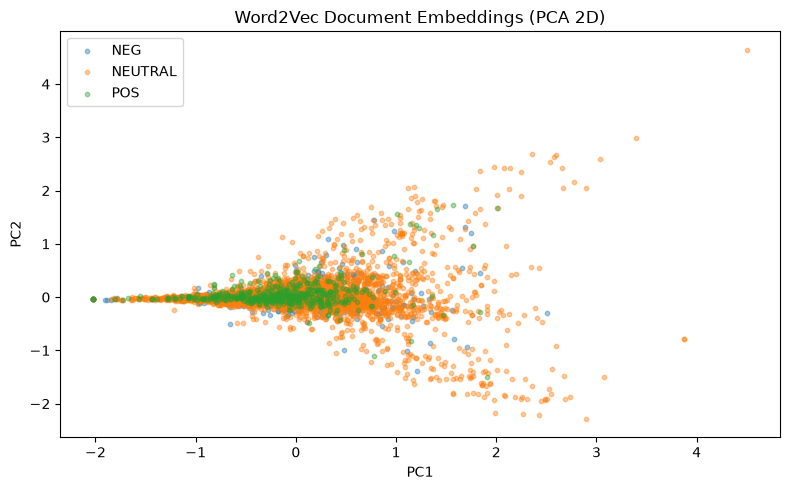

In [55]:
# PCA 2D projection of Word2Vec document embeddings coloured by sentiment class
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_w2v_train)

plt.figure(figsize=(8, 5))
for label_id, label_name in enumerate(le.classes_):
    mask = y_train == label_id
    plt.scatter(coords[mask, 0], coords[mask, 1], label=label_name, alpha=0.4, s=10)
plt.title('Word2Vec Document Embeddings (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('images/word2vec_pca.png', bbox_inches='tight', dpi=150)
plt.show()

### Word2Vec (CBOW) Analysis

Word2Vec trains a shallow neural network to predict each word from its surrounding context, producing a dense 100-dimensional vector per word that captures semantic similarity — words used in similar contexts end up close together in vector space. Each tweet is then represented as the mean of its word vectors. In essence, we convert words to vectors, and basically apply nearest neigbor for sentiment analysis.

**Compatible models:** ✓ Random Forest (accepts dense real-valued vectors including negatives). ✗ Naïve Bayes (vectors contain negative values, violating MultinomialNB's non-negative constraint). ✗ CNN / RNN / LSTM (learn their own embeddings internally).

**Pros:**
- Semantically meaningful — similar words cluster together, so synonyms share representation
- Fixed-size output regardless of tweet length

**Cons:**
- Needs large corpora for quality embeddings; ~5,800 tweets is too small
- Mean pooling destroys word order entirely
- Cannot handle out-of-vocabulary words (no subword fallback)

## 4.3 FastText

In [17]:
ft_model = GensimFT(sentences, vector_size=300, window=2, min_count=2, epochs=20, seed=42, workers=4)
print(f'Vocab size: {len(ft_model.wv)}')

X_ft_train = np.vstack([doc_vec(t, ft_model) for t in X_train])
X_ft_val   = np.vstack([doc_vec(t, ft_model) for t in X_val])
X_ft_test  = np.vstack([doc_vec(t, ft_model) for t in X_test])

Vocab size: 8358


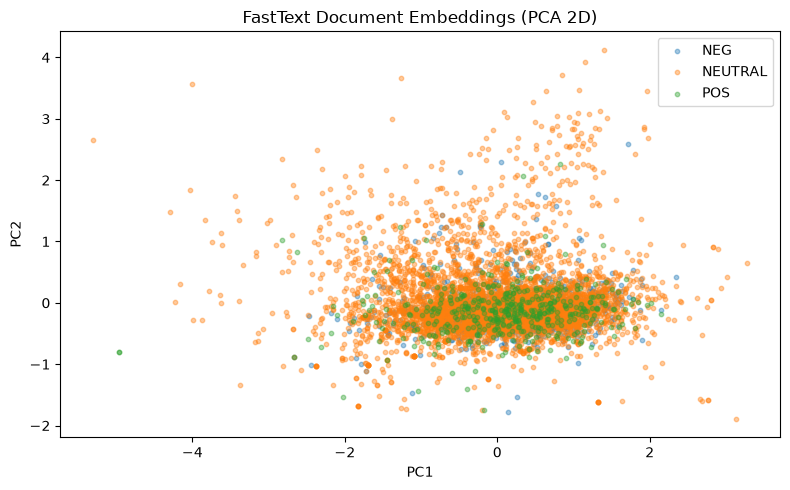

In [56]:
coords_ft = PCA(n_components=2, random_state=42).fit_transform(X_ft_train)

plt.figure(figsize=(8, 5))
for lid, lname in enumerate(le.classes_):
    mask = y_train == lid
    plt.scatter(coords_ft[mask, 0], coords_ft[mask, 1], label=lname, alpha=0.4, s=10)
plt.title('FastText Document Embeddings (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('images/fasttext_pca.png', bbox_inches='tight', dpi=150)
plt.show()

### FastText Analysis

FastText extends Word2Vec by decomposing each word into character n-grams and summing their vectors, so it can construct a meaningful embedding even for words never seen during training. This makes it particularly valuable for Arabic dialect tweets, which are full of spelling variants and out-of-vocabulary words. In essence, we divide the terms and look at more at a sub word level which helps with arabic since the same word may have the spelling variations.

**Compatible models:** ✓ Random Forest (accepts dense real-valued vectors including negatives). ✗ Naïve Bayes (vectors contain negative values). ✗ CNN / RNN / LSTM (learn their own embeddings internally).

**Pros:**
- Handles out-of-vocabulary words via subword n-grams — a major advantage for dialectal Arabic
- More robust to spelling variation than Word2Vec

**Cons:**
- Mean pooling still loses word order
- Negative values make it incompatible with Naïve Bayes
- Slower to train than Word2Vec due to character n-gram computation

---
# 5. Traditional Machine Learning Models

## 5.1 Naïve Bayes

Hyperparameter to tune: `alpha` (Laplace smoothing)

In [19]:

nb_tfidf_gs = GridSearchCV(MultinomialNB(), {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]},
                           cv=3, scoring='f1_weighted', n_jobs=-1)
nb_tfidf_gs.fit(X_tfidf_train, y_train)
print(f'Best alpha: {nb_tfidf_gs.best_params_}')

y_pred_nb_tfidf = nb_tfidf_gs.predict(X_tfidf_test)
print(classification_report(y_test, y_pred_nb_tfidf, target_names=le.classes_))

Best alpha: {'alpha': 0.1}
              precision    recall  f1-score   support

         NEG       0.44      0.20      0.27       328
     NEUTRAL       0.77      0.93      0.85      1454
         POS       0.38      0.10      0.15       155

    accuracy                           0.74      1937
   macro avg       0.53      0.41      0.42      1937
weighted avg       0.69      0.74      0.69      1937



### Note
- Notice that we did not use word2vec or fasttext here, that is because naive bayes cannot handle negative values.
- Also note that the weighted average is greatly better, than the normal average, this indicatates that the model has a better performance classifying neutral/objective classifications than actual positive and negative classifications.

## 5.2 Random Forest

In [20]:

rf_params = {'n_estimators': [100 , 200 ,  300], 'max_depth': [None, 30],
              'class_weight': ['balanced', None]}

In [21]:
# RF on sparse high-dimensional data is slow — may take a few minutes
rf_tfidf_gs = GridSearchCV(RandomForestClassifier(random_state=42), rf_params,
                           cv=3, scoring='f1_weighted', n_jobs=-1)
rf_tfidf_gs.fit(X_tfidf_train, y_train)
print(f'Best params: {rf_tfidf_gs.best_params_}')

y_pred_rf_tfidf = rf_tfidf_gs.predict(X_tfidf_test)
print(classification_report(y_test, y_pred_rf_tfidf, target_names=le.classes_))

Best params: {'class_weight': None, 'max_depth': None, 'n_estimators': 100}
              precision    recall  f1-score   support

         NEG       0.40      0.11      0.17       328
     NEUTRAL       0.76      0.95      0.85      1454
         POS       0.29      0.08      0.12       155

    accuracy                           0.74      1937
   macro avg       0.49      0.38      0.38      1937
weighted avg       0.66      0.74      0.67      1937



In [22]:
rf_w2v_gs = GridSearchCV(RandomForestClassifier(random_state=42), rf_params,
                         cv=3, scoring='f1_weighted', n_jobs=-1)
rf_w2v_gs.fit(X_w2v_train, y_train)
print(f'Best params: {rf_w2v_gs.best_params_}')

y_pred_rf_w2v = rf_w2v_gs.predict(X_w2v_test)
print(classification_report(y_test, y_pred_rf_w2v, target_names=le.classes_))

Best params: {'class_weight': 'balanced', 'max_depth': 30, 'n_estimators': 300}
              precision    recall  f1-score   support

         NEG       0.32      0.25      0.28       328
     NEUTRAL       0.78      0.86      0.82      1454
         POS       0.25      0.10      0.15       155

    accuracy                           0.70      1937
   macro avg       0.45      0.41      0.41      1937
weighted avg       0.66      0.70      0.67      1937



In [23]:
# Separate params for FastText: force balanced weights since dense 300-dim vectors
# don't give RF enough signal to detect minority classes without compensation
rf_ft_params = {'n_estimators': [100, 200, 300], 'max_depth': [None, 20, 30], 'class_weight': ['balanced']}

rf_ft_gs = GridSearchCV(RandomForestClassifier(random_state=42), rf_ft_params,
                        cv=3, scoring='f1_weighted', n_jobs=-1)
rf_ft_gs.fit(X_ft_train, y_train)
print(f'Best params: {rf_ft_gs.best_params_}')

y_pred_rf_ft = rf_ft_gs.predict(X_ft_test)
print(classification_report(y_test, y_pred_rf_ft, target_names=le.classes_))

Best params: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 200}
              precision    recall  f1-score   support

         NEG       0.31      0.26      0.28       328
     NEUTRAL       0.77      0.84      0.81      1454
         POS       0.21      0.10      0.13       155

    accuracy                           0.69      1937
   macro avg       0.43      0.40      0.41      1937
weighted avg       0.65      0.69      0.67      1937



### Summary — Traditional ML Results

Ordered by Macro F1 (primary), NEG Recall (tiebreaker):

| Rank | Model | Representation | Macro F1 | NEG Prec | NEG Recall | POS Prec | POS Recall | Accuracy |
|---|---|---|---|---|---|---|---|---|
| 1 | Naïve Bayes | TF-IDF | **0.42** | **0.44** | 0.20 | **0.38** | 0.10 | **0.74** |
| 2 | Random Forest | FastText | 0.41 | 0.31 | **0.26** | 0.21 | 0.10 | 0.69 |
| 3 | Random Forest | Word2Vec | 0.41 | 0.32 | 0.25 | 0.25 | 0.10 | 0.70 |
| 4 | Random Forest | TF-IDF | 0.38 | 0.40 | 0.11 | 0.29 | 0.08 | **0.74** |

**Best overall: NB + TF-IDF** — highest macro F1 (0.42) and highest precision on both minority classes (NEG: 0.44, POS: 0.38), meaning its predictions are the most trustworthy when it does flag a tweet as negative or positive. The trade-off is low recall — it misses most minority-class tweets but rarely mislabels them.

RF + FastText and RF + Word2Vec are tied on macro F1 (0.41) — FastText edges ahead on NEG recall (0.26 vs 0.25), making it marginally better at catching negative tweets. Both dense-embedding RF models sacrifice precision for slightly better recall balance compared to NB.

RF + TF-IDF ranks last — despite matching NB's accuracy (0.74), its very low recall on minority classes (NEG: 0.11, POS: 0.08) means it nearly always defaults to predicting NEUTRAL.

> **Note:** Accuracy is misleading here — a model that always predicts NEUTRAL would score 75%. Macro F1 and minority-class recall/precision are the true performance indicators.

---
# 6. Deep Learning Models

All three DL models follow the same input pipeline:
1. Tokenise: map each word to an integer index
2. Pad/truncate to a fixed sequence length (MAX_LEN)
3. Embedding layer: integer index → dense vector (learned during training)
4. Architecture-specific layers (Conv1d / RNN / LSTM)
5. Fully connected output layer → 3 class scores


In [38]:
# --- Shared hyperparameters ---
MAX_SEQUENCE_LEN = 50   # Pad/truncate every tweet to this many tokens
BATCH_SIZE       = 64   # Number of tweets per gradient update step
MAX_EPOCHS       = 30   # Maximum training epochs (early stopping usually cuts this short)
PATIENCE         = 5    # Stop training if val loss doesn't improve for this many epochs in a row

# --- Tokenizer: convert words → integer indices ---
tokenizer = Tokenizer(num_words=10000, oov_token='<UNK>')  # Keep the 10k most frequent words; unknown words → <UNK>
tokenizer.fit_on_texts(X_train)                             # Learn vocabulary from training data only — never from val/test

def encode_and_pad(texts):
    sequences = tokenizer.texts_to_sequences(texts)               # Replace each word with its integer index
    return pad_sequences(sequences, maxlen=MAX_SEQUENCE_LEN)      # Pad short tweets with 0s, truncate long ones to MAX_SEQUENCE_LEN

X_train_seq = encode_and_pad(X_train)  # Encoded + padded training set  — shape: (n_train, MAX_SEQUENCE_LEN)
X_val_seq   = encode_and_pad(X_val)    # Encoded + padded validation set — shape: (n_val,   MAX_SEQUENCE_LEN)
X_test_seq  = encode_and_pad(X_test)   # Encoded + padded test set       — shape: (n_test,  MAX_SEQUENCE_LEN)

# --- Class weights: penalise the model more for missing minority classes ---
class_counts  = np.bincount(y_train)                                               # Count samples per class: [NEG, NEUTRAL, POS]
class_weights = {i: len(y_train) / (3 * c) for i, c in enumerate(class_counts)}   # Inverse-frequency: rarer class → higher weight

# --- Early stopping callback: restores best weights automatically ---
early_stop = EarlyStopping(patience=PATIENCE, restore_best_weights=True, verbose=0)

print(f'Sequence shape : {X_train_seq.shape}')
print(f'Class weights  : { {k: round(v, 2) for k, v in class_weights.items()} }')

Sequence shape : (5810, 50)
Class weights  : {0: 1.97, 1: 0.44, 2: 4.16}


## 6.1 Convolutional Neural Network (CNN)

Architecture: `Embedding → Conv1d → ReLU → GlobalMaxPool → Dropout → Linear`

Hyperparameters to tune: `num_filters`, `kernel_size`, `dropout`

In [39]:
best_val_f1, best_cnn_model = 0, None  # Track the best config found so far

for num_filters, kernel_size, dropout_rate in [(64, 3, 0.3), (128, 3, 0.5), (128, 5, 0.5)]:
    model = Sequential([
        Embedding(10000, 100),                                  # Map each token index to a 100-dim trainable vector
        Conv1D(num_filters, kernel_size, activation='relu'),    # Slide a filter across the sequence to detect local n-gram patterns
        GlobalMaxPooling1D(),                                   # Keep the strongest signal from each filter, regardless of position
        Dropout(dropout_rate),                                  # Randomly drop neurons during training to reduce overfitting
        Dense(3, activation='softmax')                         # Output a probability for each class: NEG / NEUTRAL / POS
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    model.fit(
        X_train_seq, y_train,
        validation_data=(X_val_seq, y_val),
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        class_weight=class_weights, callbacks=[early_stop], verbose=0
    )

    val_f1 = f1_score(y_val, model.predict(X_val_seq, verbose=0).argmax(axis=1), average='weighted')
    print(f'filters={num_filters}, kernel={kernel_size}, dropout={dropout_rate} → val F1={val_f1:.3f}')

    if val_f1 > best_val_f1:          # Keep the model with the highest val F1
        best_val_f1, best_cnn_model = val_f1, model

y_pred_cnn = best_cnn_model.predict(X_test_seq, verbose=0).argmax(axis=1)  # Final test predictions from best config
print(f'\nBest CNN (val F1={best_val_f1:.3f}):')
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))

filters=64, kernel=3, dropout=0.3 → val F1=0.644
filters=128, kernel=3, dropout=0.5 → val F1=0.654
filters=128, kernel=5, dropout=0.5 → val F1=0.270

Best CNN (val F1=0.654):
              precision    recall  f1-score   support

         NEG       0.36      0.37      0.36       328
     NEUTRAL       0.82      0.65      0.73      1454
         POS       0.20      0.57      0.29       155

    accuracy                           0.60      1937
   macro avg       0.46      0.53      0.46      1937
weighted avg       0.69      0.60      0.63      1937



## 6.2 Recurrent Neural Network (RNN)

Architecture: `Embedding → RNN (many-to-one) → Dropout → Linear`  

Hyperparameters to tune: `hidden_dim`, `num_layers`, `dropout`

In [40]:
best_val_f1_rnn, best_rnn_model = 0, None  # Track the best RNN config found so far

for hidden_units, dropout_rate in [(64, 0.3), (128, 0.3), (128, 0.5)]:
    with tf.device('/GPU:0'):               # Force Metal GPU for model build and training
        model = Sequential([
            Embedding(10000, 100),              # Map each token index to a 100-dim trainable vector
            SimpleRNN(hidden_units, unroll=True),  # unroll=True: unrolls the time loop into a static graph — GPU-parallelisable
            Dropout(dropout_rate),              # Randomly drop neurons to reduce overfitting
            Dense(3, activation='softmax')     # Output a probability for each class: NEG / NEUTRAL / POS
        ])
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
        model.fit(
            X_train_seq, y_train,
            validation_data=(X_val_seq, y_val),
            epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
            class_weight=class_weights, callbacks=[early_stop], verbose=0
        )

    val_f1 = f1_score(y_val, model.predict(X_val_seq, verbose=0).argmax(axis=1), average='weighted')
    print(f'hidden_units={hidden_units}, dropout={dropout_rate} → val F1={val_f1:.3f}')

    if val_f1 > best_val_f1_rnn:       # Keep the model with the highest val F1
        best_val_f1_rnn, best_rnn_model = val_f1, model

y_pred_rnn = best_rnn_model.predict(X_test_seq, verbose=0).argmax(axis=1)  # Final test predictions from best config
print(f'\nBest RNN (val F1={best_val_f1_rnn:.3f}):')
print(classification_report(y_test, y_pred_rnn, target_names=le.classes_))

hidden_units=64, dropout=0.3 → val F1=0.524
hidden_units=128, dropout=0.3 → val F1=0.401
hidden_units=128, dropout=0.5 → val F1=0.275

Best RNN (val F1=0.524):
              precision    recall  f1-score   support

         NEG       0.23      0.51      0.32       328
     NEUTRAL       0.82      0.48      0.60      1454
         POS       0.11      0.25      0.15       155

    accuracy                           0.46      1937
   macro avg       0.38      0.41      0.36      1937
weighted avg       0.66      0.46      0.52      1937



## 6.3 Long Short-Term Memory (LSTM)

Architecture: `Embedding → LSTM (many-to-one) → Dropout → Linear`  
Adds 4 gates over the plain RNN: forget / input / cell / output

Hyperparameters to tune: `hidden_dim`, `num_layers`, `dropout`

In [41]:
best_val_f1_lstm, best_lstm_model = 0, None  # Track the best LSTM config found so far

for hidden_units, dropout_rate in [(64, 0.3), (128, 0.3), (128, 0.5)]:
    model = Sequential([
        Embedding(10000, 100),          # Map each token index to a 100-dim trainable vector
        LSTM(hidden_units),             # Like RNN but adds forget/input/output gates to control what to remember or discard
        Dropout(dropout_rate),          # Randomly drop neurons to reduce overfitting
        Dense(3, activation='softmax') # Output a probability for each class: NEG / NEUTRAL / POS
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    model.fit(
        X_train_seq, y_train,
        validation_data=(X_val_seq, y_val),
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        class_weight=class_weights, callbacks=[early_stop], verbose=0
    )

    val_f1 = f1_score(y_val, model.predict(X_val_seq, verbose=0).argmax(axis=1), average='weighted')
    print(f'hidden_units={hidden_units}, dropout={dropout_rate} → val F1={val_f1:.3f}')

    if val_f1 > best_val_f1_lstm:      # Keep the model with the highest val F1
        best_val_f1_lstm, best_lstm_model = val_f1, model

y_pred_lstm = best_lstm_model.predict(X_test_seq, verbose=0).argmax(axis=1)  # Final test predictions from best config
print(f'\nBest LSTM (val F1={best_val_f1_lstm:.3f}):')
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))

hidden_units=64, dropout=0.3 → val F1=0.396
hidden_units=128, dropout=0.3 → val F1=0.463
hidden_units=128, dropout=0.5 → val F1=0.488

Best LSTM (val F1=0.488):
              precision    recall  f1-score   support

         NEG       0.26      0.63      0.37       328
     NEUTRAL       0.85      0.38      0.52      1454
         POS       0.14      0.45      0.21       155

    accuracy                           0.43      1937
   macro avg       0.42      0.48      0.37      1937
weighted avg       0.69      0.43      0.47      1937



### Summary — Deep Learning Results

Ordered by Macro F1 (primary), NEG Recall (tiebreaker):

| Rank | Model | Best Config | Macro F1 | NEG Prec | NEG Recall | POS Prec | POS Recall | Accuracy |
|---|---|---|---|---|---|---|---|---|
| 1 | CNN | filters=128, kernel=3, drop=0.5 | **0.46** | 0.36 | 0.37 | 0.20 | **0.57** | **0.60** |
| 2 | LSTM | units=128, drop=0.5 | 0.37 | 0.26 | **0.63** | 0.14 | 0.45 | 0.43 |
| 3 | RNN | units=64, drop=0.3 | 0.36 | 0.23 | 0.51 | 0.11 | 0.25 | 0.46 |

**Best overall: CNN** — highest macro F1 (0.46) and best accuracy (0.60). It was not affected by the vanishing gradient the other models face.

**LSTM leads on minority-class recall** — NEG recall of 0.63 and POS recall of 0.45 are the highest of all three DL models, meaning LSTM was able to be more aggressive with its predictions but that comes at the cost of accuracy. 

**RNN underperforms both** — solid NEG recall (0.51) but the lowest macro F1 (0.36) and worst POS recall (0.25). Vanishing gradients across 50 timesteps limit the plain RNN's ability to carry sentiment signals from the beginning of a tweet to the output.

**DL vs Traditional ML:** All three DL models achieve higher NEG and POS recall than traditional models, however the traditional models perform at a macro f1 since they relied more on the neutral values.

> **Note:** Low accuracy in LSTM/RNN (0.43–0.46) is expected — class weights push the model to predict minority classes more aggressively at the cost of NEUTRAL recall. This is the correct trade-off given the dataset imbalance.

---
# 7. Comparative Evaluation

Collect all test-set results and compare across:

In [46]:
# All model predictions keyed by display name
all_predictions = {
    'NB + TF-IDF':  y_pred_nb_tfidf,
    'RF + TF-IDF':  y_pred_rf_tfidf,
    'RF + Word2Vec': y_pred_rf_w2v,
    'RF + FastText': y_pred_rf_ft,
    'CNN':           y_pred_cnn,
    'RNN':           y_pred_rnn,
    'LSTM':          y_pred_lstm,
}

# Build results DataFrame from classification_report dicts
rows = []
for name, preds in all_predictions.items():
    r = classification_report(y_test, preds, target_names=le.classes_, output_dict=True, zero_division=0)
    rows.append({
        'Model':        name,
        'Accuracy':     round(r['accuracy'], 3),
        'Macro F1':     round(r['macro avg']['f1-score'], 3),
        'Weighted F1':  round(r['weighted avg']['f1-score'], 3),
        'NEG Precision':round(r['NEG']['precision'], 3),
        'NEG Recall':   round(r['NEG']['recall'], 3),
        'POS Precision':round(r['POS']['precision'], 3),
        'POS Recall':   round(r['POS']['recall'], 3),
    })

results_df = pd.DataFrame(rows).set_index('Model').sort_values('Macro F1', ascending=False)
print(results_df.to_string())

               Accuracy  Macro F1  Weighted F1  NEG Precision  NEG Recall  POS Precision  POS Recall
Model                                                                                               
CNN               0.597     0.461        0.631          0.360       0.369          0.197       0.568
NB + TF-IDF       0.741     0.424        0.693          0.438       0.195          0.385       0.097
RF + Word2Vec     0.698     0.414        0.672          0.322       0.250          0.246       0.103
RF + FastText     0.686     0.408        0.665          0.309       0.262          0.205       0.097
RF + TF-IDF       0.736     0.380        0.674          0.400       0.110          0.293       0.077
LSTM              0.426     0.368        0.472          0.263       0.631          0.137       0.445
RNN               0.465     0.356        0.518          0.229       0.506          0.106       0.245


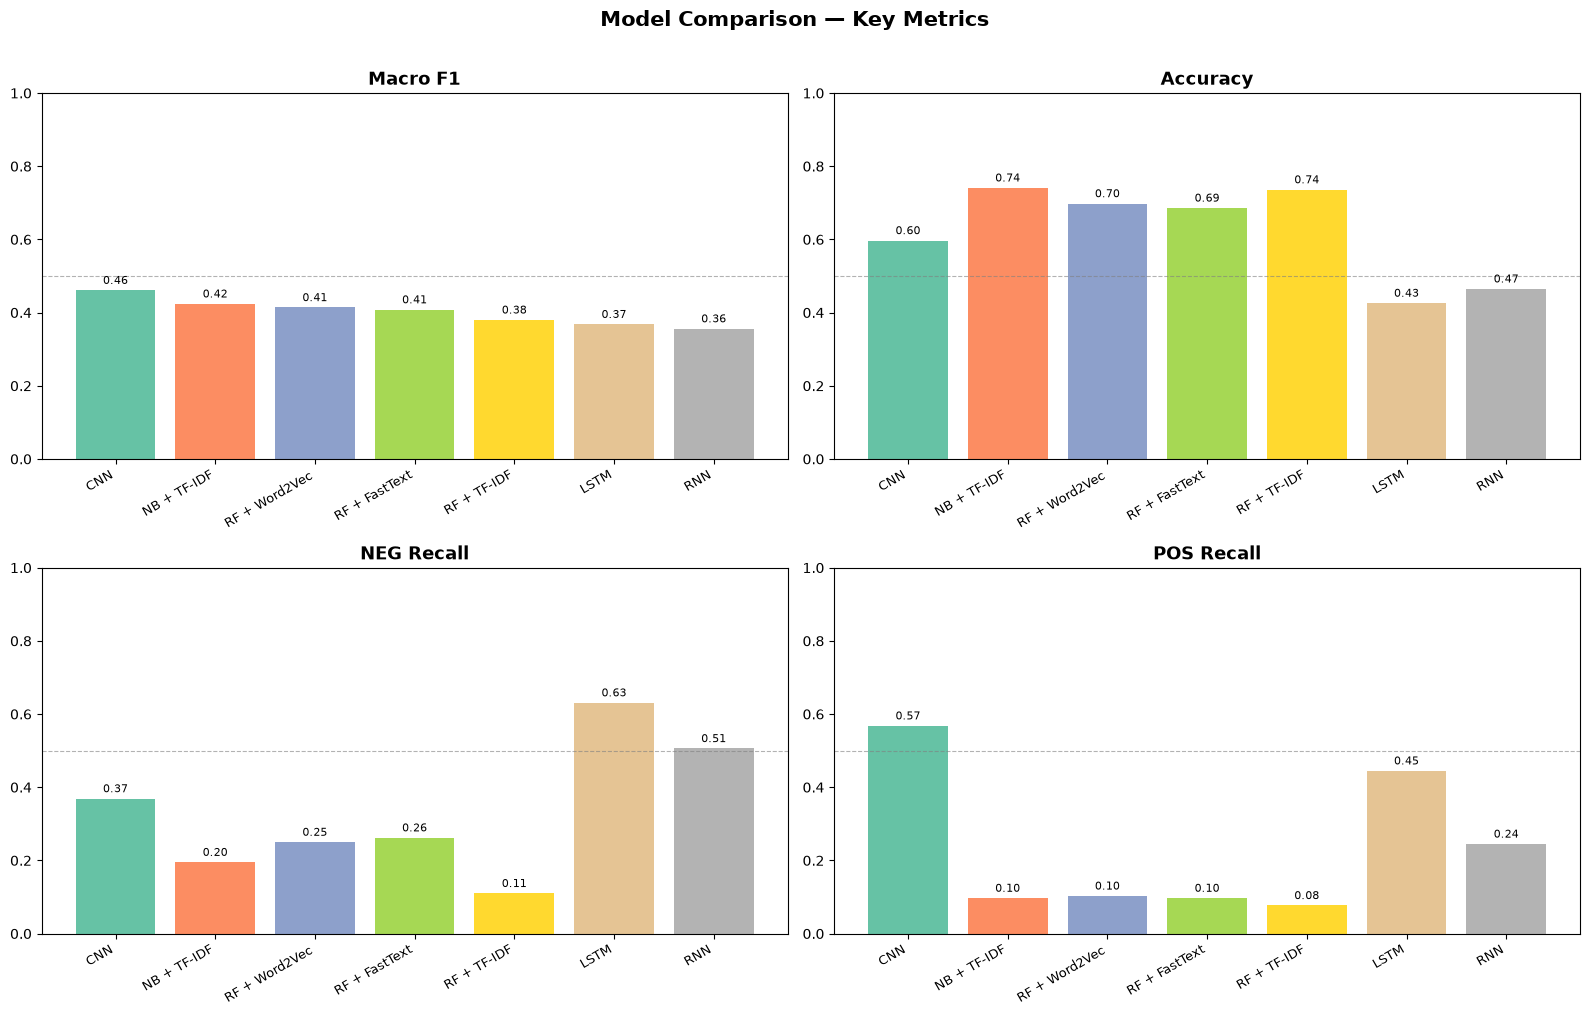

In [57]:
metrics     = ['Macro F1', 'Accuracy', 'NEG Recall', 'POS Recall']
model_names = results_df.index.tolist()
x           = np.arange(len(model_names))
width       = 0.2

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    bars = axes[i].bar(x, values, color=plt.cm.Set2(np.linspace(0, 1, len(model_names))))
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    axes[i].set_ylim(0, 1.0)
    axes[i].axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison — Key Metrics', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

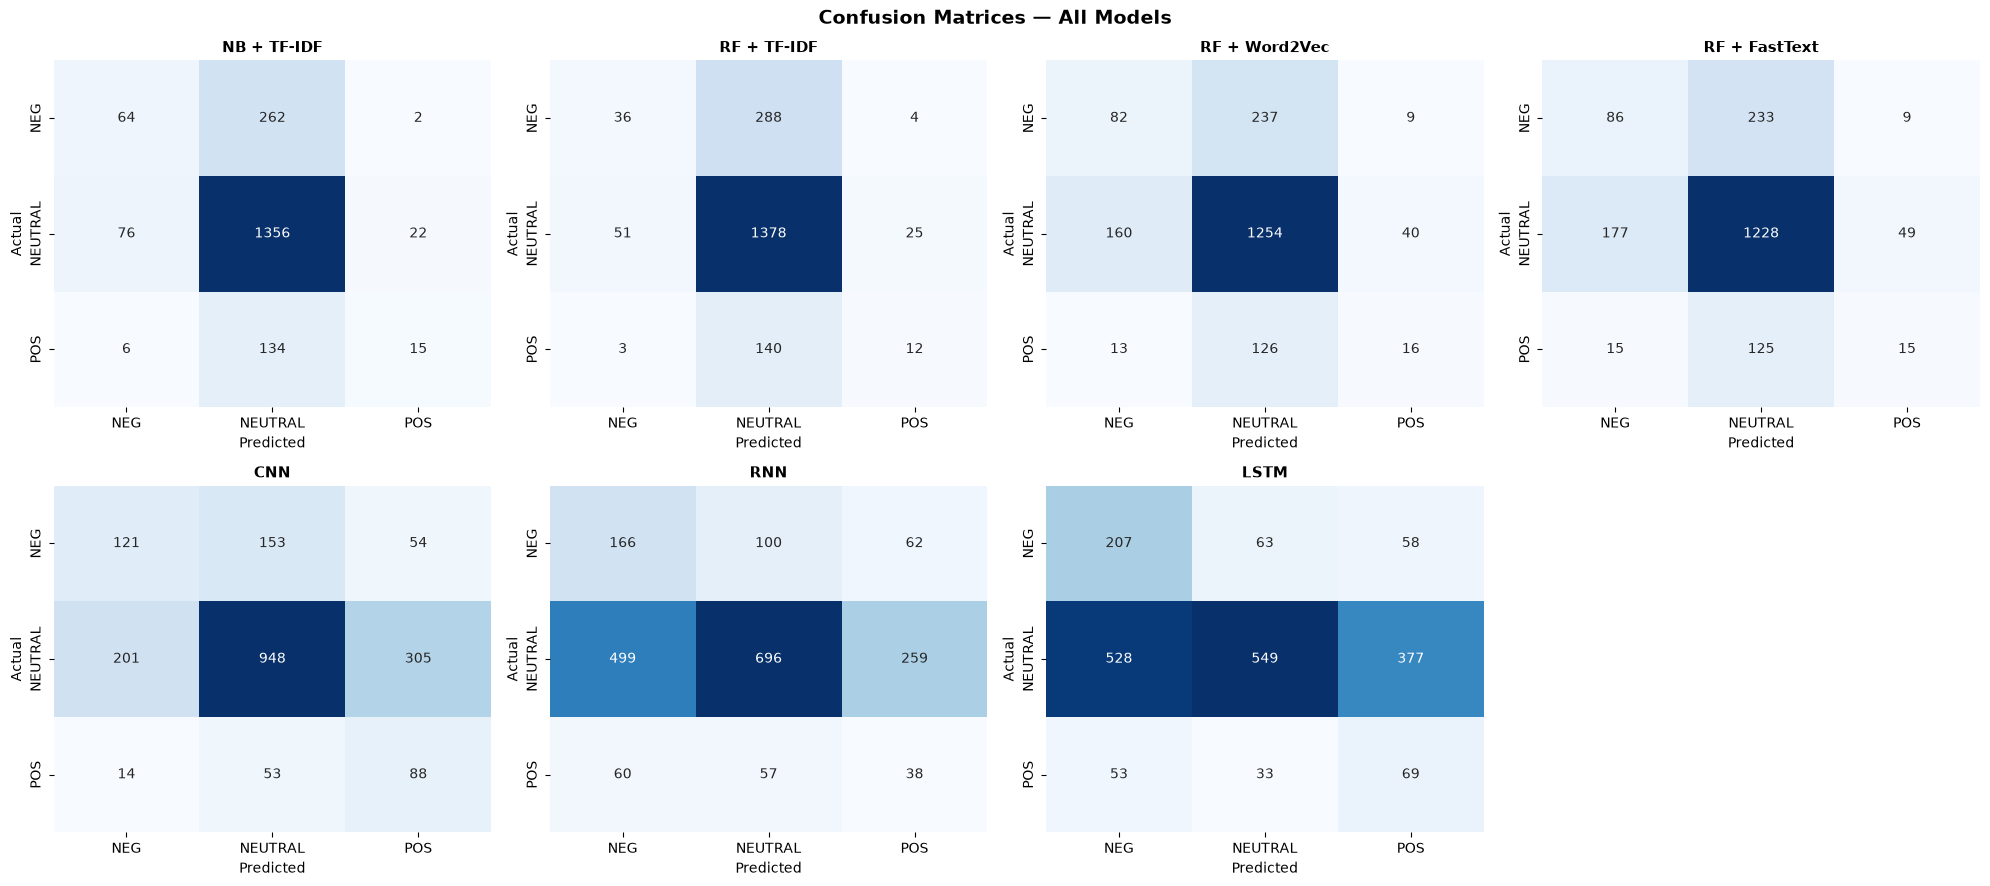

In [58]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, (name, preds) in enumerate(all_predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
    axes[i].set_title(name, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

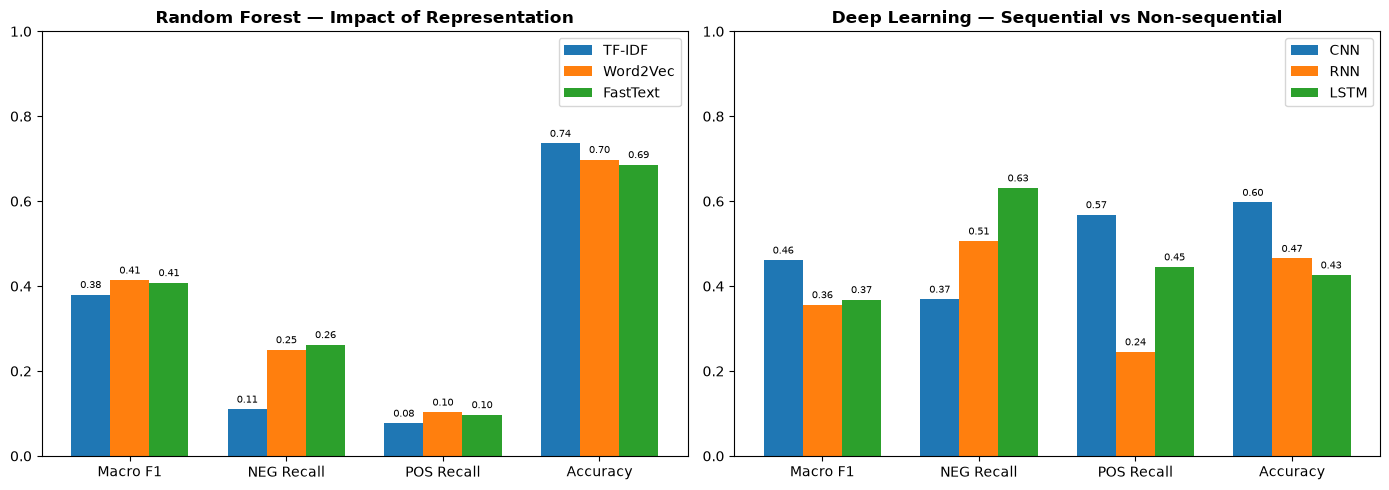

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_repr = {'TF-IDF': y_pred_rf_tfidf, 'Word2Vec': y_pred_rf_w2v, 'FastText': y_pred_rf_ft}
repr_metrics = ['Macro F1', 'NEG Recall', 'POS Recall', 'Accuracy']
rf_data = {}
for repr_name, preds in rf_repr.items():
    r = classification_report(y_test, preds, target_names=le.classes_, output_dict=True, zero_division=0)
    rf_data[repr_name] = [round(r['macro avg']['f1-score'], 3), round(r['NEG']['recall'], 3),
                          round(r['POS']['recall'], 3), round(r['accuracy'], 3)]

x = np.arange(len(repr_metrics))
width = 0.25
for j, (repr_name, vals) in enumerate(rf_data.items()):
    bars = axes[0].bar(x + j*width, vals, width, label=repr_name)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=7)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(repr_metrics)
axes[0].set_ylim(0, 1.0)
axes[0].set_title('Random Forest — Impact of Representation', fontweight='bold')
axes[0].legend()

dl_models = {'CNN': y_pred_cnn, 'RNN': y_pred_rnn, 'LSTM': y_pred_lstm}
dl_data = {}
for dl_name, preds in dl_models.items():
    r = classification_report(y_test, preds, target_names=le.classes_, output_dict=True, zero_division=0)
    dl_data[dl_name] = [round(r['macro avg']['f1-score'], 3), round(r['NEG']['recall'], 3),
                        round(r['POS']['recall'], 3), round(r['accuracy'], 3)]

for j, (dl_name, vals) in enumerate(dl_data.items()):
    bars = axes[1].bar(x + j*width, vals, width, label=dl_name)
    for bar, val in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}', ha='center', va='bottom', fontsize=7)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(repr_metrics)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Deep Learning — Sequential vs Non-sequential', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/representation_impact.png', bbox_inches='tight', dpi=150)
plt.show()

---
# 8. Analysis and Conclusions

**1. Which representation performed best and why?**

It depends on how you look at it. Overall, TF-IDF wins — NB + TF-IDF had the best macro F1 (0.42). But that is partly a compatibility advantage, not purely a representation one. Word2Vec and FastText cannot be used with Naïve Bayes due to their negative values, so they never competed on equal terms. When you hold the classifier constant and compare all three using Random Forest, dense embeddings actually come out ahead — Word2Vec (0.41) and FastText (0.41) vs TF-IDF (0.38). The gap wasn't bigger because ~5,800 training tweets is too small for embeddings trained from scratch to fully shine.

---

**2. Traditional ML vs Deep Learning — which won and why?**

Traditional ML (NB + TF-IDF) achieved the best macro F1 (0.42), but that is only due to its successful predictions of the neutral classes and not the extremes (positves and negatives). The deep learning models focused more on actually being able to detect the minor classes, which makes them take a hit in total accuracy and f1, but in terms of recall and precision the deep learning have proven to be better here. In conclusion it depends on the domain we want to use our models in, if you want to be generalized and not be able to truly distinguish the minor classes then we go with traditional, but if being able to distinguish is your end goal even if it tanks your accuracy then deep learning wins.

---

**3. Sequential (RNN/LSTM) vs non-sequential (CNN) — what did you find?**

CNN outperformed both RNN and LSTM on macro F1 (0.46 vs 0.37 and 0.36). For short tweets (≤50 tokens), CNN's ability to detect local word patterns in parallel is more effective than processing the sequence step by step. RNN and LSTM suffer from vanishing gradients and struggle to carry sentiment signals across the full sequence, making them less effective here despite being architecturally more expressive.

---

**4. Impact of class imbalance — how did you handle it?**

The dataset is heavily skewed — 75% of tweets are NEUTRAL, leaving only 17% NEG and 8% POS. Without correction, any model would just predict NEUTRAL for almost everything and still score 75% accuracy. We handled this with two techniques: inverse-frequency class weights (penalising the model more for missing minority classes during training), and stratified splitting (preserving class proportions across train/val/test). We also prioritised macro F1 over accuracy as the main metric, since accuracy is misleading when one class dominates.

---

**5. Challenges encountered and how you addressed them.**

The biggest challenge was Arabic dialect variation - some words can be morphed but still have the same semantic meaning, as well as even a letter can have 1-3 variations, which is why we have the stop words, normalization, and data restructuring in the earlier steps. This way we bring the language complexity down to a more simple one the model can handle.

---

**6. What would you do differently with more data or more time?**

With more data, I would focus on the deep learning models more, this is where they thrive afterall. Giving the model the better fit use case would lead to better results and even better capabilites, such as being able to even detect dialects in arabic.